In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import re


# ============================================================
# Helpers
# ============================================================
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip().strip("'").strip('"') for c in df.columns]
    return df


def proto_time_to_key(t: str) -> str:
    # "00.05" -> "0005"
    return str(t).strip().replace(".", "").zfill(4)


def key_to_proto_time(key: str) -> str:
    key = str(key).zfill(4)
    return f"{key[:2]}.{key[2:]}"


def get_proto_time_cols(df: pd.DataFrame, range_col: str = "range_m"):
    if range_col not in df.columns:
        raise ValueError(f"Prototype CSV missing range column '{range_col}'. Found: {list(df.columns)[:10]} ...")

    pat = re.compile(r"^\d{2}\.\d{2}$")  # matches 00.05 etc.
    time_cols = [c for c in df.columns if c != range_col and pat.match(str(c))]

    if not time_cols:
        raise ValueError(
            "No Prototype time columns found like '00.05'. "
            f"Example columns: {list(df.columns)[:15]}"
        )

    time_cols_sorted = sorted(time_cols, key=lambda x: int(str(x).replace(".", "")))
    return range_col, time_cols_sorted


def timestamp_to_time_key(ts: pd.Series) -> pd.Series:
    """
    Convert timestamp -> "HHMM" string
    Example: 2026-01-26 00:05:00 -> "0005"
    """
    t = pd.to_datetime(ts, errors="coerce")
    return t.dt.strftime("%H%M")


# ============================================================
# 1) moving average
# ============================================================
def moving_average(x, k: int):
    k = int(k)
    if k % 2 == 0:
        k += 1
    w = np.ones(k) / k
    return np.convolve(np.asarray(x, float), w, mode="same")


# ============================================================
# 2) FFT low-pass denoise (keep your exact version)
# ============================================================
def fft_lowpass_fixed_fc(x, dr: float, fc: float = 0.0125, order: int = 6, pad_frac: float = 0.10):
    x = np.asarray(x, dtype=float)
    n = len(x)

    if np.isnan(x).any():
        idx = np.arange(n)
        good = ~np.isnan(x)
        if good.sum() < 2:
            return np.full_like(x, np.nan)
        x = np.interp(idx, idx[good], x[good])

    mean_x = float(np.nanmean(x))
    x0 = x - mean_x

    pad = int(max(32, pad_frac * n))
    pad = min(pad, n - 2) if n > 2 else 0

    if pad > 0:
        xpad = np.concatenate([x0[pad:0:-1], x0, x0[-2:-pad-2:-1]])
    else:
        xpad = x0.copy()

    N = len(xpad)
    X = np.fft.rfft(xpad)
    f = np.fft.rfftfreq(N, d=dr)  # cycles/m
    H = 1.0 / np.sqrt(1.0 + (f / fc) ** (2 * order))

    ypad = np.fft.irfft(X * H, n=N)
    y = ypad[pad:pad + n] if pad > 0 else ypad
    return y + mean_x


# ============================================================
# 3) PBox-like edge: gradient of log10(NRB) + pick most negative
# ============================================================
def pbox_like_pbl_from_profile(
    nrb_arr,
    r,
    *,
    rmin: float,
    rmax: float,
    smooth_win: int = 7,
    use_log10: bool = True,
    eps: float = 1e-10,
):
    """
    PBox-like PBL:
      - optional smooth
      - optional log10 transform
      - gradient wrt range
      - choose most negative gradient within [rmin, rmax]
    Returns: (pbl_m, grad_min_value, mode_string)
    """
    r = np.asarray(r, float)
    y = np.asarray(nrb_arr, float)

    # smooth first (like many prototype methods)
    y_s = moving_average(y, smooth_win)

    # log transform (very important for edge detection stability)
    if use_log10:
        y_s = np.log10(np.clip(y_s, eps, np.inf))

    # gradient (d/dz)
    g = np.gradient(y_s, r)  # same length as r

    mask = (r >= rmin) & (r <= rmax) & np.isfinite(g) & np.isfinite(r)
    if not np.any(mask):
        return np.nan, np.nan, "no_data"

    idx_local = np.nanargmin(g[mask])  # most negative gradient
    idx = np.where(mask)[0][idx_local]

    return float(r[idx]), float(g[idx]), "loggrad_min"


# ============================================================
# 4) MAIN: Prototype CSV + miniMPL CSV (timestamp) -> output CSV in pbl_day
# ============================================================
def run_pbl_from_proto_and_minimpl_csv(
    *,
    proto_csv: str | Path,
    minimpl_csv: str | Path,
    output_dir: str | Path,
    # Prototype columns
    proto_range_col: str = "range_m",
    # miniMPL columns
    mpl_timestamp_col: str = "timestamp",
    mpl_col: str = "pbls_m",
    rmin_col: str = "min_pbls_m",
    rmax_col: str = "max_pbls_m",
    # denoise params
    fc: float = 0.0125,
    fft_order: int = 6,
    pad_frac: float = 0.10,
    # PBox-like params
    smooth_win: int = 7,
    use_log10: bool = True,
    # output naming
    out_prefix: str = "pbl_day",
):
    proto_csv = Path(proto_csv)
    minimpl_csv = Path(minimpl_csv)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ---------- Load ----------
    df_proto = normalize_columns(pd.read_csv(proto_csv))
    df_mpl = normalize_columns(pd.read_csv(minimpl_csv))

    # ---------- Prototype structure ----------
    proto_range_col, proto_time_cols = get_proto_time_cols(df_proto, range_col=proto_range_col)

    r = pd.to_numeric(df_proto[proto_range_col], errors="coerce").to_numpy(float)
    dr = float(np.nanmedian(np.diff(r)))
    rmin_clip = float(np.nanmin(r))
    rmax_clip = float(np.nanmax(r))

    # ---------- miniMPL structure ----------
    for need in [mpl_timestamp_col, mpl_col, rmin_col, rmax_col]:
        if need not in df_mpl.columns:
            raise ValueError(f"miniMPL CSV missing column '{need}'. Found: {list(df_mpl.columns)}")

    # Make time_key from timestamp: "HHMM"
    df_mpl = df_mpl.copy()
    df_mpl[mpl_timestamp_col] = pd.to_datetime(df_mpl[mpl_timestamp_col], errors="coerce")
    df_mpl = df_mpl.dropna(subset=[mpl_timestamp_col])

    df_mpl["time_key"] = timestamp_to_time_key(df_mpl[mpl_timestamp_col]).astype(str).str.zfill(4)
    df_mpl = df_mpl.dropna(subset=["time_key"])

    # Make numeric + drop duplicates on time_key
    for c in [mpl_col, rmin_col, rmax_col]:
        df_mpl[c] = pd.to_numeric(df_mpl[c], errors="coerce")
    df_mpl = df_mpl.sort_values(mpl_timestamp_col).drop_duplicates(subset=["time_key"], keep="first")

    # Build proto -> time_key
    proto_map = pd.DataFrame({
        "proto_col": proto_time_cols,
        "time_key": [proto_time_to_key(c) for c in proto_time_cols],
    })
    proto_map["time_key_int"] = proto_map["time_key"].astype(int)

    df_mpl["time_key_int"] = df_mpl["time_key"].astype(int)

    # ---------- Exact merge then nearest for missing ----------
    meta = proto_map.merge(df_mpl, on="time_key", how="left", suffixes=("", "_mpl"))
    missing = meta[mpl_col].isna() | meta[rmin_col].isna() | meta[rmax_col].isna()

    meta["Time_mapping"] = "exact"
    if missing.any():
        near = pd.merge_asof(
            meta.loc[missing, ["proto_col", "time_key", "time_key_int"]].sort_values("time_key_int"),
            df_mpl.sort_values("time_key_int"),
            on="time_key_int",
            direction="nearest"
        )
        for c in df_mpl.columns:
            if c == "time_key_int":
                continue
            meta.loc[missing, c] = near[c].to_numpy()
        meta.loc[missing, "Time_mapping"] = "nearest"

    # ---------- Run pipeline ----------
    den = pd.DataFrame({proto_range_col: r})
    rows = []

    for _, m in meta.iterrows():
        proto_col = m["proto_col"]
        time_key = m["time_key"]

        y = pd.to_numeric(df_proto[proto_col], errors="coerce").to_numpy(float)

        # 1) FFT denoise (keep)
        y_dn = fft_lowpass_fixed_fc(y, dr=dr, fc=fc, order=fft_order, pad_frac=pad_frac)
        den[proto_col] = y_dn

        # dynamic window (clip)
        rmin = float(m[rmin_col]) if np.isfinite(m[rmin_col]) else rmin_clip
        rmax = float(m[rmax_col]) if np.isfinite(m[rmax_col]) else rmax_clip
        rmin_use = max(rmin, rmin_clip)
        rmax_use = min(rmax, rmax_clip)

        # 2) PBox-like pick (log-gradient min)
        pbl_pbox, grad_min, mode = pbox_like_pbl_from_profile(
            y_dn, r, rmin=rmin_use, rmax=rmax_use, smooth_win=smooth_win, use_log10=use_log10
        )

        pbl_mpl = float(m[mpl_col]) if np.isfinite(m[mpl_col]) else np.nan

        rows.append({
            "time_key": time_key,
            "proto_time": key_to_proto_time(time_key),
            "Time_mapping": m["Time_mapping"],
            "PBL_MPL_m": pbl_mpl,
            "rmin_m": rmin,
            "rmax_m": rmax,
            "PBL_PBoxLike_m": pbl_pbox,              # <-- this is your new "match PBox" PBL
            "Chosen_mode": mode,
            "Edge_strength_grad_min": grad_min,      # useful diagnostic
            "Delta_PBoxLike_minus_MPL_m": (pbl_pbox - pbl_mpl) if np.isfinite(pbl_pbox) and np.isfinite(pbl_mpl) else np.nan,
            "NRB_all_nan": bool(np.all(np.isnan(y))),
        })

    res = pd.DataFrame(rows).sort_values("time_key").reset_index(drop=True)

    # ---------- Save outputs ----------
    day_str = proto_csv.stem  # e.g. "26-01-2026"
    out_results = output_dir / f"{out_prefix}_{day_str}_PBoxLike_loggradMin.csv"
    out_den = output_dir / f"{out_prefix}_{day_str}_NRB_denoised_FFT.csv"

    res.to_csv(out_results, index=False)
    den.to_csv(out_den, index=False)

    return out_results, out_den


In [2]:
proto_csv = "/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/26-01-2026.csv"
minimpl_csv = "/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbls_26-01-2026_0005_0035_to_2335.csv"
out_dir = "/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day"

out_results, out_den = run_pbl_from_proto_and_minimpl_csv(
    proto_csv=proto_csv,
    minimpl_csv=minimpl_csv,
    output_dir=out_dir,
    proto_range_col="range_m",
    mpl_timestamp_col="timestamp",
    mpl_col="pbls_m",
    rmin_col="min_pbls_m",
    rmax_col="max_pbls_m",
    smooth_win=7,
    use_log10=True,
)

print("Saved:", out_results)
print("Saved denoised:", out_den)


Saved: /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/pbl_day_26-01-2026_PBoxLike_loggradMin.csv
Saved denoised: /Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/pbl_day_26-01-2026_NRB_denoised_FFT.csv


In [3]:
path = "/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day/pbl_day_26-01-2026_PBoxLike_loggradMin.csv"

df_den = pd.read_csv(path)

# quick check
print(df_den.shape)
print(df_den.columns[:10])
df_den.head()

(48, 11)
Index(['time_key', 'proto_time', 'Time_mapping', 'PBL_MPL_m', 'rmin_m',
       'rmax_m', 'PBL_PBoxLike_m', 'Chosen_mode', 'Edge_strength_grad_min',
       'Delta_PBoxLike_minus_MPL_m'],
      dtype='object')


,time_key,proto_time,Time_mapping,PBL_MPL_m,rmin_m,rmax_m,PBL_PBoxLike_m,Chosen_mode,Edge_strength_grad_min,Delta_PBoxLike_minus_MPL_m,NRB_all_nan
0,5,0.05,exact,2098.5472,1798.5472,2398.5472,2186.25,loggrad_min,-0.005306,87.7028,False
1,35,0.35,exact,2128.5264,1828.5264,2428.5264,2107.50,loggrad_min,-0.004124,-21.0264,False
2,105,1.05,exact,2098.5472,1798.5472,2398.5472,2163.75,loggrad_min,-0.003608,65.2028,False
3,135,1.35,exact,2038.5888,1738.5888,2338.5888,2055.00,loggrad_min,-0.004198,16.4112,False
4,205,2.05,exact,2098.5472,1798.5472,2398.5472,2077.50,loggrad_min,-0.004393,-21.0472,False


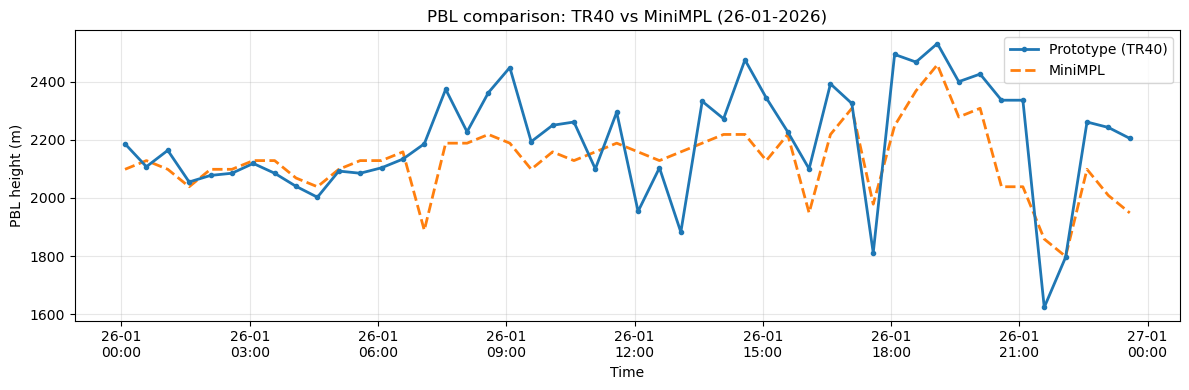

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def add_datetime_from_day_and_proto_time(df, day_str, proto_time_col="proto_time", out_col="datetime"):
    """
    day_str: "26-01-2026"
    proto_time: "00.05" or "23.35"
    -> datetime: 2026-01-26 00:05:00
    """
    df = df.copy()
    base_date = pd.to_datetime(day_str, format="%d-%m-%Y", errors="coerce")
    if pd.isna(base_date):
        raise ValueError(f"Cannot parse day_str='{day_str}' with format DD-MM-YYYY")

    # "00.05" -> "00:05"
    t = df[proto_time_col].astype(str).str.strip().str.replace(".", ":", regex=False)

    # combine date + time
    df[out_col] = pd.to_datetime(
        base_date.strftime("%Y-%m-%d") + " " + t + ":00",
        errors="coerce"
    )
    return df


def plot_pbl_prototype_vs_minimpl(
    df_proto,
    df_mpl,
    *,
    proto_col="PBL_TR40_m",
    mpl_col="pbls_m",
    datetime_col_proto="datetime",
    datetime_col_mpl="timestamp",
    title="PBL comparison: Prototype TR40 vs MiniMPL",
    figsize=(12, 4),
):
    df_proto = df_proto.copy()
    df_mpl = df_mpl.copy()

    df_proto[datetime_col_proto] = pd.to_datetime(df_proto[datetime_col_proto], errors="coerce")
    df_mpl[datetime_col_mpl] = pd.to_datetime(df_mpl[datetime_col_mpl], errors="coerce")

    df_proto = df_proto.dropna(subset=[datetime_col_proto]).sort_values(datetime_col_proto)
    df_mpl = df_mpl.dropna(subset=[datetime_col_mpl]).sort_values(datetime_col_mpl)

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        df_proto[datetime_col_proto],
        df_proto[proto_col],
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=3,
        label="Prototype (TR40)",
        zorder=3,
    )

    ax.plot(
        df_mpl[datetime_col_mpl],
        df_mpl[mpl_col],
        linestyle="--",
        linewidth=2,
        label="MiniMPL",
        zorder=2,
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("PBL height (m)")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m\n%H:%M"))
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Paths (your real files)
# ------------------------------------------------------------
DAY = "26-01-2026"

pbl_day_dir = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day")
tr40_csv = pbl_day_dir / f"pbl_day_{DAY}_PBoxLike_loggradMin.csv"

minimpl_csv = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday") / \
              f"pbls_{DAY}_0005_0035_to_2335.csv"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df_tr40 = pd.read_csv(tr40_csv)
df_mpl = pd.read_csv(minimpl_csv)

# Your miniMPL uses timestamp column (per your message)
# If your file column is literally "timestamp", keep as is
# If it's "datetime", just change datetime_col_mpl in plot call.

# Add datetime to TR40 output from day + proto_time
df_tr40 = add_datetime_from_day_and_proto_time(df_tr40, DAY, proto_time_col="proto_time", out_col="datetime")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plot_pbl_prototype_vs_minimpl(
    df_proto=df_tr40,
    df_mpl=df_mpl,
    proto_col="PBL_PBoxLike_m",
    mpl_col="pbls_m",
    datetime_col_proto="datetime",
    datetime_col_mpl="timestamp",
    title=f"PBL comparison: TR40 vs MiniMPL ({DAY})",
)


In [5]:
pbox_path = Path("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/ALT-result-(26-30)-01-2026.csv")

PBox = pd.read_csv(pbox_path)
PBox

,Time,ALT from MPL,ALT Prototype,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1/26/26 12:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN
1,1/26/26 12:35 AM,2129.0,2104.0,NaN,NaN,NaN,NaN
2,1/26/26 1:05 AM,2099.0,2070.0,NaN,NaN,NaN,NaN
3,1/26/26 1:35 AM,2039.0,2051.0,NaN,NaN,NaN,NaN
4,1/26/26 2:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
PBox["datetime"] = pd.to_datetime(
    PBox["Time"],
    format="%m/%d/%y %I:%M %p",   # 👈 matches: 1/26/26 12:05 AM
    errors="coerce"
)
PBox.columns = (
    PBox.columns
        .str.strip()          # remove leading/trailing spaces
        .str.replace(" ", "_", regex=False)
)
PBox

,Time,ALT_from_MPL,ALT_Prototype,Unnamed:_3,Unnamed:_4,Unnamed:_5,Unnamed:_6,datetime
0,1/26/26 12:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN,2026-01-26 00:05:00
1,1/26/26 12:35 AM,2129.0,2104.0,NaN,NaN,NaN,NaN,2026-01-26 00:35:00
2,1/26/26 1:05 AM,2099.0,2070.0,NaN,NaN,NaN,NaN,2026-01-26 01:05:00
3,1/26/26 1:35 AM,2039.0,2051.0,NaN,NaN,NaN,NaN,2026-01-26 01:35:00
4,1/26/26 2:05 AM,2099.0,2074.0,NaN,NaN,NaN,NaN,2026-01-26 02:05:00
...,...,...,...,...,...,...,...,...
234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_27710/2664201976.py:137: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  PBox[pbox_time_col] = pd.to_datetime(PBox[pbox_time_col], errors="coerce")


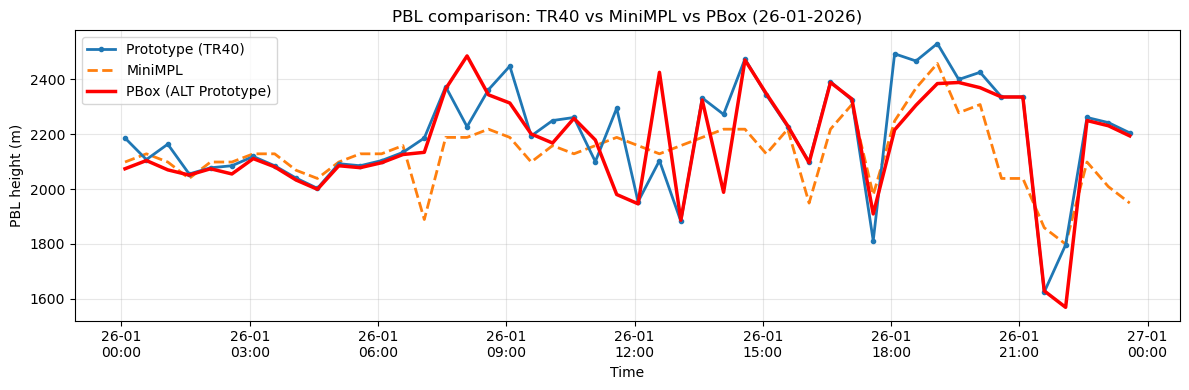

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def add_datetime_from_day_and_proto_time(df, day_str, proto_time_col="proto_time", out_col="datetime"):
    """
    day_str: "26-01-2026"
    proto_time: "00.05" or "23.35"
    -> datetime: 2026-01-26 00:05:00
    """
    df = df.copy()
    base_date = pd.to_datetime(day_str, format="%d-%m-%Y", errors="coerce")
    if pd.isna(base_date):
        raise ValueError(f"Cannot parse day_str='{day_str}' with format DD-MM-YYYY")

    # "00.05" -> "00:05"
    t = df[proto_time_col].astype(str).str.strip().str.replace(".", ":", regex=False)

    df[out_col] = pd.to_datetime(
        base_date.strftime("%Y-%m-%d") + " " + t + ":00",
        errors="coerce"
    )
    return df


def plot_pbl_tr40_vs_minimpl_vs_pbox(
    df_tr40,
    df_mpl,
    df_pbox,
    *,
    tr40_col="PBL_TR40_m",
    mpl_col="pbls_m",
    pbox_col="ALT Prototype",
    dt_tr40="datetime",
    dt_mpl="timestamp",
    dt_pbox="timestamp",
    title="PBL comparison: TR40 vs MiniMPL vs PBox",
    figsize=(12, 4),
):
    df_tr40 = df_tr40.copy()
    df_mpl = df_mpl.copy()
    df_pbox = df_pbox.copy()

    df_tr40[dt_tr40] = pd.to_datetime(df_tr40[dt_tr40], errors="coerce")
    df_mpl[dt_mpl] = pd.to_datetime(df_mpl[dt_mpl], errors="coerce")
    df_pbox[dt_pbox] = pd.to_datetime(df_pbox[dt_pbox], errors="coerce")

    df_tr40[tr40_col] = pd.to_numeric(df_tr40[tr40_col], errors="coerce")
    df_mpl[mpl_col] = pd.to_numeric(df_mpl[mpl_col], errors="coerce")
    df_pbox[pbox_col] = pd.to_numeric(df_pbox[pbox_col], errors="coerce")

    df_tr40 = df_tr40.dropna(subset=[dt_tr40, tr40_col]).sort_values(dt_tr40)
    df_mpl = df_mpl.dropna(subset=[dt_mpl, mpl_col]).sort_values(dt_mpl)
    df_pbox = df_pbox.dropna(subset=[dt_pbox, pbox_col]).sort_values(dt_pbox)

    fig, ax = plt.subplots(figsize=figsize)

    # TR40 (Prototype-derived)
    ax.plot(
        df_tr40[dt_tr40],
        df_tr40[tr40_col],
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=3,
        label="Prototype (TR40)",
        zorder=4,
    )

    # MiniMPL
    ax.plot(
        df_mpl[dt_mpl],
        df_mpl[mpl_col],
        linestyle="--",
        linewidth=2,
        label="MiniMPL",
        zorder=3,
    )

    # PBox ALT Prototype
    ax.plot(
        df_pbox[dt_pbox],
        df_pbox[pbox_col],
        linestyle="-",
        linewidth=2.5,
        color="red",
        label="PBox (ALT Prototype)",
        zorder=5,
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("PBL height (m)")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m\n%H:%M"))
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Paths (your real files)
# ------------------------------------------------------------
DAY = "26-01-2026"

pbl_day_dir = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbl_day")
tr40_csv = pbl_day_dir / f"pbl_day_{DAY}_PBoxLike_loggradMin.csv"

minimpl_csv = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday") / \
              f"pbls_{DAY}_0005_0035_to_2335.csv"

pbox_path = Path("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/ALT-result-(26-30)-01-2026.csv")

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df_tr40 = pd.read_csv(tr40_csv)
df_mpl = pd.read_csv(minimpl_csv)
PBox = pd.read_csv(pbox_path)

# Add datetime to TR40 output from day + proto_time
df_tr40 = add_datetime_from_day_and_proto_time(df_tr40, DAY, proto_time_col="proto_time", out_col="datetime")

# Clean PBox column names (important: your file may have trailing spaces)
PBox.columns = [c.strip() for c in PBox.columns]

# --- choose PBox time column (pick the right one) ---
# If your PBox has "Time" instead of "timestamp", change here:
pbox_time_col = "timestamp" if "timestamp" in PBox.columns else "Time"

# Parse and filter PBox to the same DAY
PBox[pbox_time_col] = pd.to_datetime(PBox[pbox_time_col], errors="coerce")
day_dt = pd.to_datetime(DAY, format="%d-%m-%Y")
PBox = PBox.dropna(subset=[pbox_time_col])
PBox = PBox[(PBox[pbox_time_col] >= day_dt) & (PBox[pbox_time_col] < day_dt + pd.Timedelta(days=1))]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plot_pbl_tr40_vs_minimpl_vs_pbox(
    df_tr40=df_tr40,
    df_mpl=df_mpl,
    df_pbox=PBox,
    tr40_col="PBL_PBoxLike_m",
    mpl_col="pbls_m",
    pbox_col="ALT Prototype",
    dt_tr40="datetime",
    dt_mpl="timestamp",
    dt_pbox=pbox_time_col,
    title=f"PBL comparison: TR40 vs MiniMPL vs PBox ({DAY})",
)


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_steps_one_time(
    *,
    proto_csv,
    minimpl_csv,
    time_key="0005",                 # choose: "0005", "0035", ...
    proto_range_col="range_m",
    mpl_timestamp_col="timestamp",
    mpl_col="pbls_m",
    rmin_col="min_pbls_m",
    rmax_col="max_pbls_m",
    # pipeline params (match your run function)
    fc=0.0125,
    fft_order=6,
    pad_frac=0.10,
    smooth_win=7,
    use_log10=True,
    eps=1e-10,
    save_path=None,                 # e.g. "debug_0005.png"
    show=True,
):
    # --- load + normalize columns (use your helper)
    df_proto = normalize_columns(pd.read_csv(proto_csv))
    df_mpl = normalize_columns(pd.read_csv(minimpl_csv))

    # --- get proto time columns
    proto_range_col, proto_time_cols = get_proto_time_cols(df_proto, range_col=proto_range_col)

    # --- range + dr
    r = pd.to_numeric(df_proto[proto_range_col], errors="coerce").to_numpy(float)
    good_r = np.isfinite(r)
    if good_r.sum() < 3:
        raise ValueError("range_m has too many NaNs")
    dr = float(np.nanmedian(np.diff(r[good_r])))

    # --- pick the prototype column that matches time_key
    proto_col = key_to_proto_time(time_key)  # "0005" -> "00.05"
    if proto_col not in df_proto.columns:
        raise ValueError(f"Prototype does not have column '{proto_col}'. Example: {proto_time_cols[:10]}")

    y_raw = pd.to_numeric(df_proto[proto_col], errors="coerce").to_numpy(float)

    # --- prep mpl time_key + get rmin/rmax for this time (exact/nearest)
    df_mpl = df_mpl.copy()
    df_mpl[mpl_timestamp_col] = pd.to_datetime(df_mpl[mpl_timestamp_col], errors="coerce")
    df_mpl = df_mpl.dropna(subset=[mpl_timestamp_col])

    for c in [mpl_col, rmin_col, rmax_col]:
        df_mpl[c] = pd.to_numeric(df_mpl[c], errors="coerce")

    df_mpl["time_key"] = timestamp_to_time_key(df_mpl[mpl_timestamp_col]).astype(str).str.zfill(4)
    df_mpl["time_key_int"] = df_mpl["time_key"].astype(int)
    df_mpl = df_mpl.sort_values("time_key_int").drop_duplicates("time_key", keep="first")

    # find exact or nearest
    target_int = int(str(time_key).zfill(4))
    exact = df_mpl[df_mpl["time_key_int"] == target_int]
    if len(exact) == 1:
        row = exact.iloc[0]
        mapping = "exact"
    else:
        # nearest by time_key_int
        idx = np.argmin(np.abs(df_mpl["time_key_int"].to_numpy() - target_int))
        row = df_mpl.iloc[idx]
        mapping = "nearest"

    rmin = float(row[rmin_col]) if np.isfinite(row[rmin_col]) else float(np.nanmin(r))
    rmax = float(row[rmax_col]) if np.isfinite(row[rmax_col]) else float(np.nanmax(r))
    pbl_mpl = float(row[mpl_col]) if np.isfinite(row[mpl_col]) else np.nan

    rmin_use = max(rmin, float(np.nanmin(r)))
    rmax_use = min(rmax, float(np.nanmax(r)))

    # =========================================================
    # PIPELINE STEPS (exactly aligned to your code logic)
    # =========================================================

    # A) FFT denoise (this is what you actually use for PBL picking)
    y_dn = fft_lowpass_fixed_fc(y_raw, dr=dr, fc=fc, order=fft_order, pad_frac=pad_frac)

    # B) smooth for edge detector (inside pbox_like...)
    y_sm = moving_average(y_dn, smooth_win)

    # C) log10
    if use_log10:
        y_log = np.log10(np.clip(y_sm, eps, np.inf))
        g = np.gradient(y_log, r)
    else:
        y_log = y_sm.copy()
        g = np.gradient(y_sm, r)

    # D) choose most negative gradient within window
    mask = (r >= rmin_use) & (r <= rmax_use) & np.isfinite(g) & np.isfinite(r)
    if np.any(mask):
        idx_local = np.nanargmin(g[mask])
        idx = np.where(mask)[0][idx_local]
        pbl_pick = float(r[idx])
        g_pick = float(g[idx])
    else:
        pbl_pick = np.nan
        g_pick = np.nan

    # =========================================================
    # PLOTS
    # =========================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

    # --- panel 1: raw vs fft denoise
    ax = axes[0]
    ax.plot(y_raw, r, label="raw (Prototype)")
    ax.plot(y_dn, r, label="FFT denoised")
    ax.axhline(rmin_use, linestyle="--", label="rmin/rmax window")
    ax.axhline(rmax_use, linestyle="--")
    if np.isfinite(pbl_pick):
        ax.axhline(pbl_pick, linestyle=":", label=f"PBL pick = {pbl_pick:.0f} m")
    if np.isfinite(pbl_mpl):
        ax.axhline(pbl_mpl, linestyle="-.", label=f"MiniMPL PBL = {pbl_mpl:.0f} m")
    ax.set_xlabel("NRB")
    ax.set_ylabel("range (m)")
    ax.set_title("Step A: Raw → FFT denoise")
    ax.legend(loc="best")

    # --- panel 2: smoothed & log space (what gradient sees)
    ax = axes[1]
    ax.plot(y_sm, r, label="moving avg on denoised")
    ax.set_xlabel("NRB (smoothed)")
    ax.set_title(f"Step B: moving avg (k={smooth_win})")
    ax.legend(loc="best")

    ax2 = ax.twiny()
    ax2.plot(y_log, r, label="log10(smoothed)")
    ax2.set_xlabel("log10(NRB)")
    # don’t add another legend (too busy)

    # --- panel 3: gradient + pick
    ax = axes[2]
    ax.plot(g, r, label="gradient wrt range")
    ax.axhline(rmin_use, linestyle="--", label="rmin/rmax window")
    ax.axhline(rmax_use, linestyle="--")
    if np.isfinite(pbl_pick):
        ax.axhline(pbl_pick, linestyle=":", label=f"pick @ {pbl_pick:.0f} m (g={g_pick:.2e})")
    ax.set_xlabel("d/dz (log10(NRB))" if use_log10 else "d/dz (NRB)")
    ax.set_title("Step C: gradient + pick most negative")
    ax.legend(loc="upper right")


    fig.suptitle(
        f"{Path(proto_csv).name} @ {proto_col} (time_key={time_key}) | mapping={mapping} | "
        f"rmin={rmin_use:.0f} rmax={rmax_use:.0f}",
        y=1.02
    )
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "proto_col": proto_col,
        "time_key": time_key,
        "mapping": mapping,
        "rmin_use": rmin_use,
        "rmax_use": rmax_use,
        "pbl_pick": pbl_pick,
        "pbl_mpl": pbl_mpl,
        "grad_pick": g_pick,
    }


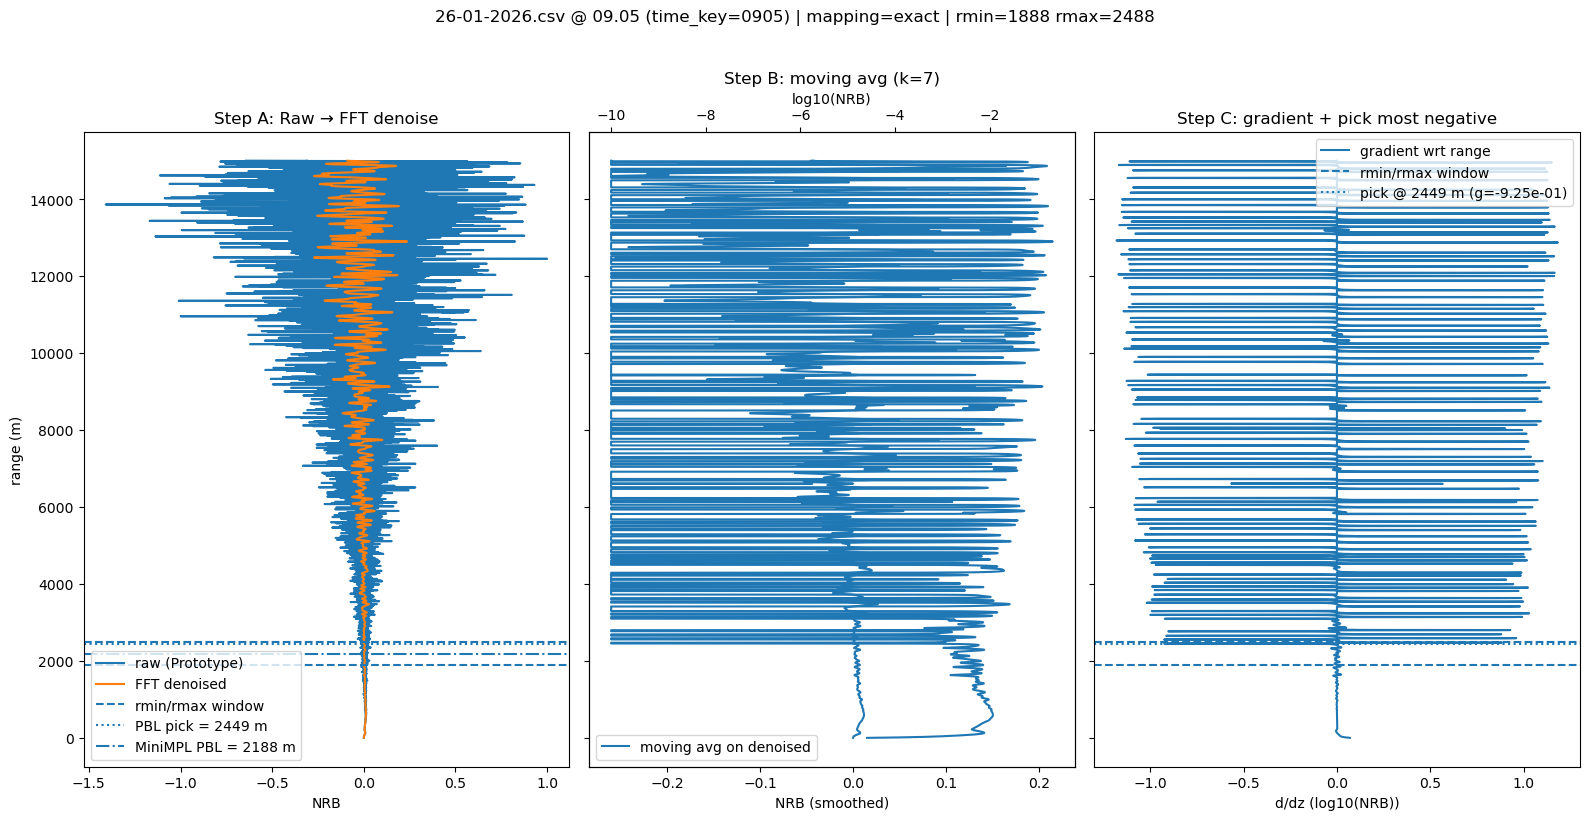

{'proto_col': '09.05', 'time_key': '0905', 'mapping': 'exact', 'rmin_use': 1888.485, 'rmax_use': 2488.485, 'pbl_pick': 2448.75, 'pbl_mpl': 2188.485, 'grad_pick': -0.925300342375668}


In [34]:
proto_csv = "/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/26-01-2026.csv"
mpl_csv   = "/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbls_26-01-2026_0005_0035_to_2335.csv"

info = plot_steps_one_time(
    proto_csv=proto_csv,
    minimpl_csv=mpl_csv,
    time_key="0905",
    save_path="debug_26-01-2026_0005.png",
)
print(info)
